In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("Position_Salaries.csv")

In [3]:
df = pd.read_csv("dataset/Position_Salaries.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'dataset/Position_Salaries.csv'

In [4]:
df = pd.read_csv("Position_Salaries.csv")

In [5]:
df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [6]:
df.shape

(10, 3)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Position  10 non-null     str  
 1   Level     10 non-null     int64
 2   Salary    10 non-null     int64
dtypes: int64(2), str(1)
memory usage: 372.0 bytes


In [8]:
df.describe()

,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


In [9]:
df.columns

Index(['Position', 'Level', 'Salary'], dtype='str')

In [10]:
df.isnull().sum()

Position    0
Level       0
Salary      0
dtype: int64

In [11]:
X = df[['Level']]
y = df['Salary']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
print(X_train.shape)
print(X_test.shape)

(8, 1)
(2, 1)


In [14]:
poly = PolynomialFeatures(degree=3)

In [15]:
X_train_poly = poly.fit_transform(X_train)

In [16]:
X_test_poly = poly.transform(X_test)

In [17]:
model = LinearRegression()

model.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0. ,157144.24,-44274.84, 3925.87]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-8.366e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[894.35, 15.36, 0.66, 0. ]"


In [18]:
y_pred = model.predict(X_test_poly)

In [19]:
prediction = pd.DataFrame({
    "Actual Salary": y_test,
    "Predicted Salary": y_pred
})

prediction

,Actual Salary,Predicted Salary
8,500000,606335.600512
1,50000,84934.891292


In [20]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE :", mae)

MAE : 70635.24590164087


In [21]:
mse = mean_squared_error(y_test, y_pred)
print("MSE :", mse)

MSE : 6263853282.860252


In [22]:
r2 = r2_score(y_test, y_pred)
print("R2 Score :", r2)

R2 Score : 0.8762695647830073


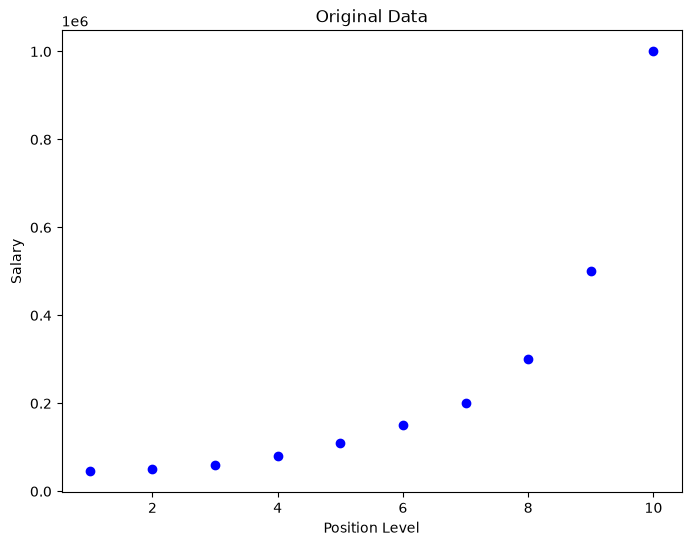

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(
    X,
    y,
    color='blue'
)

plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.title("Original Data")

plt.show()

In [24]:
X_grid = np.arange(min(X.values), max(X.values), 0.1)
X_grid = X_grid.reshape(-1,1)

TypeError: only 0-dimensional arrays can be converted to Python scalars

In [25]:
X_grid = np.arange(X.values.min(), X.values.max(), 0.1).reshape(-1, 1)

In [26]:
X_grid_poly = poly.transform(X_grid)

C:\Users\lucky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [27]:
X_grid = pd.DataFrame(
    np.arange(X['Level'].min(), X['Level'].max(), 0.1),
    columns=['Level']
)

In [28]:
X_grid_poly = poly.transform(X_grid)

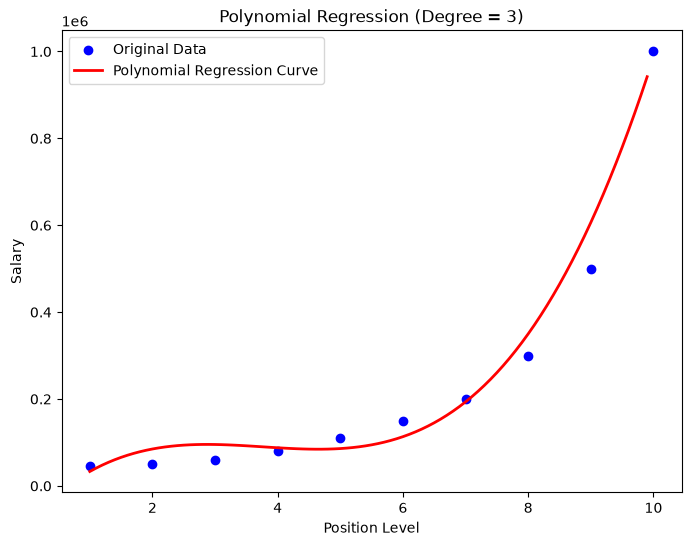

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(X, y, color='blue', label='Original Data')

plt.plot(
    X_grid,
    model.predict(X_grid_poly),
    color='red',
    linewidth=2,
    label='Polynomial Regression Curve'
)

plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.title("Polynomial Regression (Degree = 3)")
plt.legend()

plt.show()

In [30]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)
print("Mean Squared Error  :", mse)
print("R2 Score            :", r2)

Mean Absolute Error : 70635.24590164087
Mean Squared Error  : 6263853282.860252
R2 Score            : 0.8762695647830073


In [31]:
new_level = pd.DataFrame({'Level':[6.5]})

new_level_poly = poly.transform(new_level)

predicted_salary = model.predict(new_level_poly)

print("Predicted Salary =", predicted_salary[0])

Predicted Salary = 145306.94600786257


In [ ]:
Observation 1

The Polynomial Regression model successfully captures the nonlinear relationship between position level and salary.

Observation 2

The regression curve passes close to most data points, giving better predictions than a straight-line model.

Observation 3

The high R² score and low MAE/MSE indicate that the model fits the dataset well.

In [ ]:
CONCLUSION:
This project used Polynomial Regression to predict employee salaries based on position level. Since the relationship between position level and salary is nonlinear, Polynomial Regression provided better predictions than Linear Regression. Polynomial Features of degree 3 transformed the data, allowing the model to capture the curved trend. The model was evaluated using MAE, MSE, and R² Score, showing good prediction accuracy. Unlike Linear Regression, which fits only a straight line, Polynomial Regression can model complex nonlinear relationships. Its main advantage for this dataset is its ability to accurately represent salary growth across different position levels, resulting in improved prediction performance.